# YT-Diag — project walkthrough

Run this top to bottom to see the whole pipeline on real data, and to **check the
claims** in `02_Data/eda.md` and `CHANGELOG.md` yourself rather than taking them
on trust. Every section ends with something you can verify.

**Ground rules for this notebook** (worth keeping if you add cells):

- It is an *interface* to the pipeline, not a second copy of it. Cells import from
  `02_Data/` and `03_Models/` and call the real functions.
- Never paste label, split or cleaning logic into a cell. If you need it, import it.
- Restart-and-run-all must work. No hidden state, no cell that depends on you having
  run something out of order.
- Nothing here writes to the dataset. The one cell that could (`clean_retrospective`)
  is run in its read-only default mode.

Kernel: the project venv. If the imports below fail, run
`.venv/bin/python -m ipykernel install --user --name ytdiag` and pick the `ytdiag`
kernel.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore", category=UserWarning)

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
sys.path.insert(0, os.path.join(ROOT, "02_Data"))
sys.path.insert(0, os.path.join(ROOT, "03_Models"))
DATA = os.path.join(ROOT, "02_Data", "processed")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SEED = 0                      # every random choice below uses this
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("root:", ROOT)
print("dataset present:", os.path.isdir(DATA))

root: /Users/emmanuelgyabaah/GitHub/yt-diag
dataset present: True


## 1. What one video actually is

Nothing in this project is a database — every video is a folder on disk. That is what
makes the pipeline resumable: a crash just means re-running the same command.

In [2]:
from clean_retrospective import done_videos

videos = list(done_videos(DATA))   # generator -> list, we iterate it repeatedly
print(f"{len(videos)} completed videos")

# a video with the full set of artefacts, chosen deterministically
category, vid, vdir = next(v for v in videos if os.path.exists(os.path.join(v[2], "audio_features.json")))
print(f"\nexample: {category}/{vid}\n")
for f in sorted(os.listdir(vdir)):
    p = os.path.join(vdir, f)
    size = sum(os.path.getsize(os.path.join(p, x)) for x in os.listdir(p)) if os.path.isdir(p) else os.path.getsize(p)
    print(f"  {f:26s} {size/1024:8.1f} KB")

1860 completed videos

example: comedy/-ERhH_wltqU

  .done                           0.0 KB
  audio_features.json             5.0 KB
  captions.en.srt               101.3 KB
  frames                       1787.9 KB
  label.json                      0.3 KB
  metadata.json                   2.4 KB
  metadata_extra.json             0.4 KB
  thumbnail.webp                 81.2 KB
  transcript.txt                 47.6 KB
  transcript_clean.txt           17.5 KB
  transcript_info.json            0.1 KB
  visual_features.json            0.7 KB


In [3]:
meta = json.load(open(os.path.join(vdir, "metadata.json")))
extra = json.load(open(os.path.join(vdir, "metadata_extra.json")))
print("title      :", meta["title"][:70])
print("channel    :", meta.get("channel"), f"({meta.get('channel_follower_count'):,} subs)")
print("duration   :", meta["duration"], "s")
print("views      :", f"{meta['view_count']:,}")
print("published  :", extra.get("published_at_utc"), "| language:", extra.get("default_audio_language") or extra.get("default_language"))
print("is_short   :", extra.get("is_short"))

title      : Kanchana 3 - Back to Back Comedy Scenes 😂 | Raghava Lawrence | Kovai S
channel    : None (2,090,000 subs)
duration   : 2091 s
views      : 5,876,497
published  : 2026-06-04T13:00:09Z | language: ta
is_short   : false


## 2. The transcript repair — check it yourself

**Claim to verify:** YouTube auto-captions repeat every phrase about three times, because
captions scroll in overlapping windows. If true, word counts were inflated ~3× and every
text statistic was really measuring repetition.

`dup8_ratio` is the fraction of 8-word sequences that are repeats of an earlier one.

In [4]:
from clean_retrospective import dup8_ratio, parse_srt_text_lines, dedup_rolling_lines

# pick a video whose transcript came from auto-captions and was rebuilt
sample = None
for c, v, d in videos:
    info = os.path.join(d, "transcript_info.json")
    if (os.path.exists(os.path.join(d, "transcript_clean.txt"))
            and os.path.exists(os.path.join(d, "transcript.txt"))
            and json.load(open(info)).get("source") == "auto_captions"):
        raw = open(os.path.join(d, "transcript.txt"), encoding="utf-8", errors="replace").read()
        if len(raw.split()) > 400:
            sample = (c, v, d); break

c, v, d = sample
raw = open(os.path.join(d, "transcript.txt"), encoding="utf-8", errors="replace").read()
clean = open(os.path.join(d, "transcript_clean.txt"), encoding="utf-8", errors="replace").read()
print(f"{c}/{v}\n")
print("RAW (first 300 chars) — look for the repetition:")
print(" ", repr(raw[:300]), "\n")
print("CLEANED:")
print(" ", repr(clean[:300]), "\n")
print(f"words   raw {len(raw.split()):5d}  ->  clean {len(clean.split()):5d}   (ratio {len(clean.split())/len(raw.split()):.2f})")
print(f"dup8    raw {dup8_ratio(raw.split()):.3f}  ->  clean {dup8_ratio(clean.split()):.3f}")

comedy/-ERhH_wltqU

RAW (first 300 chars) — look for the repetition:
  'Oh my god, the big guy has arrived. The pilgrim has arrived. The pilgrim has arrived. The pilgrim has arrived. Hi Put it like that, Put it like that, Put it like that, my my my dance is great, dance is great, dance is great, we are sharing love here we are sharing love here we are sharing love here ' 

CLEANED:
  "Oh my god, the big guy has arrived.\nThe pilgrim has arrived.\nHi\nPut it like that,\nmy\ndance is great,\nwe are sharing love here\n.\nI'm also sharing.\nWhat a blessing. [Screaming]\nHow was the Super America trip\n? I haven't\nseen you for six months. I was so happy. I'm like this.\nWhat is my daughter doing?" 

words   raw  9445  ->  clean  3478   (ratio 0.37)
dup8    raw 0.302  ->  clean 0.003


In [5]:
# Does it hold across the dataset? Sample 120 rebuilt auto-caption transcripts.
import random
rng = random.Random(SEED)
cands = [(c, v, d) for c, v, d in videos
         if os.path.exists(os.path.join(d, "transcript_clean.txt"))
         and os.path.exists(os.path.join(d, "transcript.txt"))]
rows = []
for c, v, d in rng.sample(cands, 120):
    rw = open(os.path.join(d, "transcript.txt"), encoding="utf-8", errors="replace").read().split()
    cw = open(os.path.join(d, "transcript_clean.txt"), encoding="utf-8", errors="replace").read().split()
    if len(rw) < 20: continue
    rows.append({"raw_dup8": dup8_ratio(rw), "clean_dup8": dup8_ratio(cw), "word_ratio": len(cw)/len(rw)})
rep = pd.DataFrame(rows)
print(rep.describe().loc[["count", "mean", "50%", "max"]].round(3))
print("\n-> raw dup8 clusters near 0.35 (each phrase ~3x); cleaned near 0.")

       raw_dup8  clean_dup8  word_ratio
count   113.000     113.000     113.000
mean      0.343       0.012       0.352
50%       0.347       0.000       0.343
max       0.827       0.866       0.792



-> raw dup8 clusters near 0.35 (each phrase ~3x); cleaned near 0.


## 3. The 20 frames, and why they are not evenly spaced

Twelve of the twenty land in the **first 60 seconds**; the remaining eight cover
everything after. Viewers decide whether to keep watching in the opening seconds, so
that is where the retention signal is. Even spacing would spend most frames on the part
of the video most viewers never reach.

duration 2091s -> frame timestamps (s):
  [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 186.9, 440.8, 694.7, 948.6, 1202.4, 1456.3, 1710.2, 1964.1]

12 of 20 frames are inside the first 60 seconds


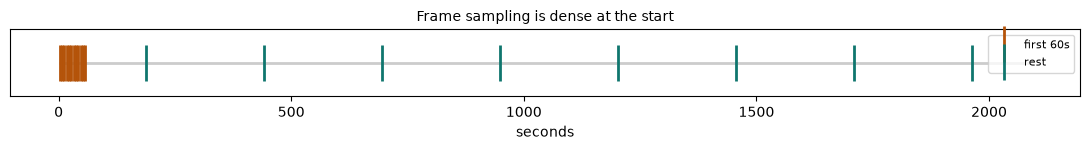

In [6]:
from collect_and_extract import compute_frame_timestamps

dur = meta["duration"]
ts = compute_frame_timestamps(dur, 20)
print(f"duration {dur}s -> frame timestamps (s):")
print(" ", [round(t, 1) for t in ts])
print(f"\n{sum(1 for t in ts if t <= 60)} of 20 frames are inside the first 60 seconds")

fig, ax = plt.subplots(figsize=(11, 1.6))
ax.hlines(0, 0, dur, color="0.8", lw=2)
ax.plot([t for t in ts if t <= 60], [0]*sum(1 for t in ts if t <= 60), "|", ms=26, mew=2, color="#b45309", label="first 60s")
ax.plot([t for t in ts if t > 60], [0]*sum(1 for t in ts if t > 60), "|", ms=26, mew=2, color="#0f766e", label="rest")
ax.set_yticks([]); ax.set_xlabel("seconds"); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Frame sampling is dense at the start", fontsize=10); plt.tight_layout(); plt.show()

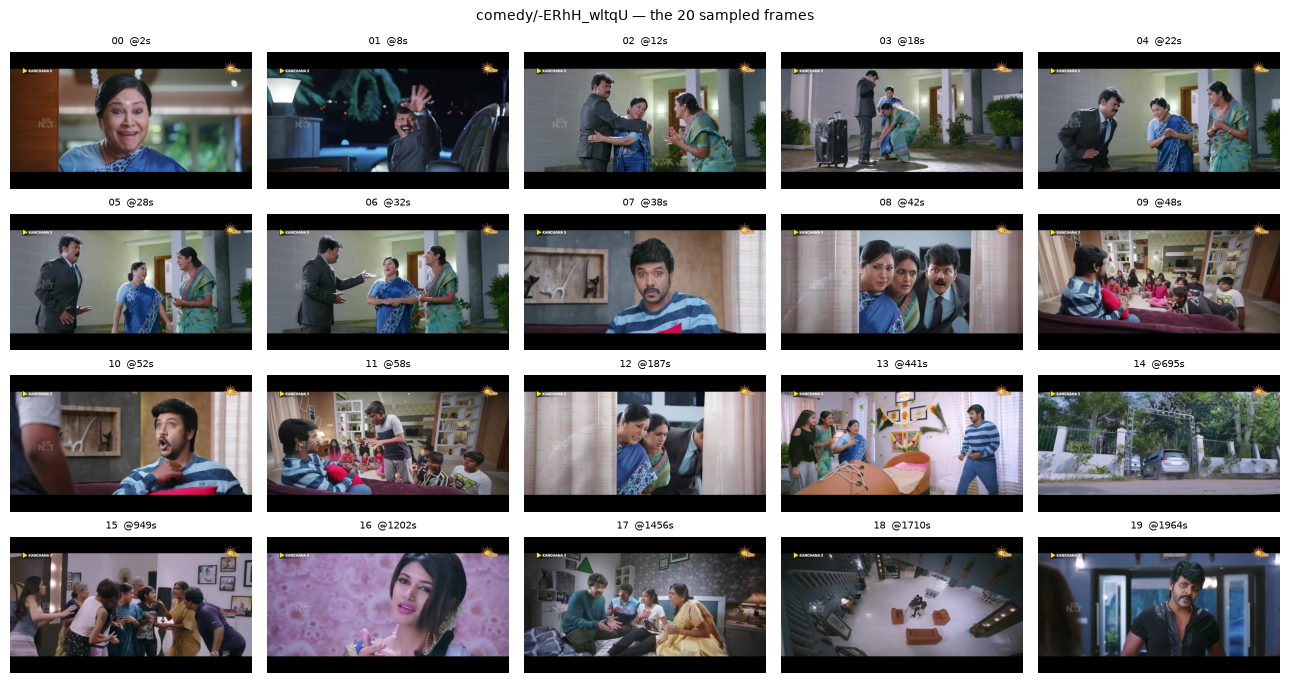

In [7]:
# The frames themselves
from PIL import Image
frames = sorted(os.listdir(os.path.join(vdir, "frames")))
fig, axes = plt.subplots(4, 5, figsize=(13, 7))
for ax, fn, t in zip(axes.ravel(), frames, ts):
    ax.imshow(Image.open(os.path.join(vdir, "frames", fn)))
    ax.set_title(f"{fn.replace('frame_','').replace('.jpg','')}  @{t:.0f}s", fontsize=7)
    ax.axis("off")
plt.suptitle(f"{category}/{vid} — the 20 sampled frames", fontsize=10)
plt.tight_layout(); plt.show()

## 4. The engineered features, including the colour-temperature fix

`visual_features.json` is 15 hand-designed numbers; `audio_features.json` is 92
(88 standard eGeMAPS values plus 4 pause measurements). Hand-designed features are
*interpretable*: the explanation layer can say "dark, no face" rather than "neuron 291
was low".

**Claim to verify:** the old colour-temperature values were physically impossible, and
the corrected ones are plausible.

In [8]:
vis = json.load(open(os.path.join(vdir, "visual_features.json")))
aud = json.load(open(os.path.join(vdir, "audio_features.json")))
print("visual_features.json — thumbnail block:")
for k, val in vis["thumbnail"].items():
    print(f"   {k:24s} {val}")
print("\nvisual_features.json — frame aggregates + CCT provenance:")
for k, val in vis.items():
    if k != "thumbnail":
        print(f"   {k:24s} {val}")
print("\naudio_features.json — pauses:", aud["pauses"])
print(f"audio_features.json — {len(aud['egemaps'])} eGeMAPS values, e.g.")
for k in list(aud["egemaps"])[:4]:
    print(f"   {k:48s} {aud['egemaps'][k]:.3f}")

visual_features.json — thumbnail block:
   cct                      5018.650082264867
   brightness               118.68961588541667
   saturation               84.65308159722223
   contrast                 77.71253570674585
   has_face                 True
   face_count               2
   max_face_area_ratio      0.08567816840277778
   face_centrality          0.27871227155010697

visual_features.json — frame aggregates + CCT provenance:
   frames_mean_cct          6924.485957307804
   frames_std_cct           1225.421686568972
   frames_mean_brightness   88.0454475368924
   frames_mean_saturation   53.493463704427086
   frames_mean_contrast     67.77539898986507
   frames_has_face_ratio    0.9
   frames_mean_max_face_area_ratio 0.03369661458333333
   cct_thumbnail_valid      True
   cct_frames_valid         20
   cct_frames_total         20
   cct_version              2
   cct_recomputed_at_utc    2026-09-01T13:12:09Z

audio_features.json — pauses: {'pause_count': 26, 'total_pause_se

D65 white (equal linear RGB) -> 6503.5 K   [textbook: 6504]
warm  (1.0, 0.6, 0.3)        -> 3684.1 K
cool  (0.6, 0.75, 1.0)       -> 9527.1 K
pure green                   -> None  (far from the Planckian locus, so undefined)

The OLD implementation returned 5520 K for white and up to 5.0e9 K for some frames.

frames_mean_cct over 1857 videos: min 2520  median 5671  max 17757 K


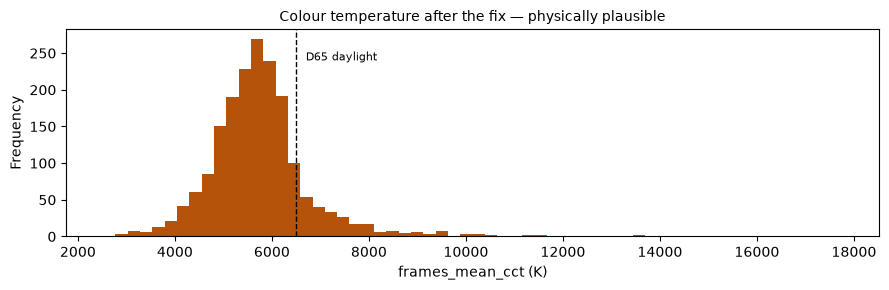

In [9]:
# The correctness test: a known colour must give a known temperature.
from collect_and_extract import correlated_color_temp, srgb_to_linear, MAX_DUV
print("D65 white (equal linear RGB) ->", round(correlated_color_temp((1,1,1)), 1), "K   [textbook: 6504]")
print("warm  (1.0, 0.6, 0.3)        ->", round(correlated_color_temp((1,.6,.3)), 1), "K")
print("cool  (0.6, 0.75, 1.0)       ->", round(correlated_color_temp((.6,.75,1)), 1), "K")
print("pure green                   ->", correlated_color_temp((0,1,0)), " (far from the Planckian locus, so undefined)")
print("\nThe OLD implementation returned 5520 K for white and up to 5.0e9 K for some frames.")

# distribution across the dataset, after the fix
ccts = []
for c, v, d in videos:
    p = os.path.join(d, "visual_features.json")
    if os.path.exists(p):
        m = json.load(open(p)).get("frames_mean_cct")
        if m: ccts.append(m)
s = pd.Series(ccts)
print(f"\nframes_mean_cct over {len(s)} videos: min {s.min():.0f}  median {s.median():.0f}  max {s.max():.0f} K")
s.plot.hist(bins=60, figsize=(9,3), color="#b45309")
plt.axvline(6504, color="k", ls="--", lw=1); plt.text(6700, plt.ylim()[1]*.85, "D65 daylight", fontsize=8)
plt.xlabel("frames_mean_cct (K)"); plt.title("Colour temperature after the fix — physically plausible", fontsize=10)
plt.tight_layout(); plt.show()

## 5. One table, both datasets

The two datasets do not have the same features, so each gets an **adapter** that maps it
onto one canonical table with group-prefixed columns. Every experiment is then a choice
of prefixes rather than a second pipeline.

In [10]:
from ytdiag.adapters import load_retrospective
from ytdiag.features import available_groups, select_columns, LABEL_ONLY

df = load_retrospective(DATA)
print(f"{len(df)} rows x {df.shape[1]} columns; groups with data: {available_groups(df)}")
print(f"labelled: {df.label.notna().sum()}  |  viral rate: {df.label.mean():.3f}")

cols = select_columns(df, ("meta", "sched", "vis", "aud"))
print(f"\nmodel-input columns: {len(cols)}")
for p in ("meta", "sched", "vis", "aud"):
    n = [c for c in cols if c.startswith(p + "__")]
    print(f"   {p+'__':8s} {len(n):3d} columns, mean missing {df[n].isna().mean().mean():.1%}")

# the registry refuses to hand out label-only columns as inputs
print("\nlabel-only columns are never selectable:", not any(c in LABEL_ONLY for c in cols))

1860 rows x 135 columns; groups with data: ['meta', 'sched', 'vis', 'aud', 'asset']
labelled: 1854  |  viral rate: 0.236

model-input columns: 125
   meta__    14 columns, mean missing 7.2%
   sched__    4 columns, mean missing 0.3%
   vis__     15 columns, mean missing 2.0%
   aud__     92 columns, mean missing 2.3%

label-only columns are never selectable: True


In [11]:
# Missingness is structural and blocky -- not random. Listwise deletion is impossible.
miss = df[cols].isna()
print("rows that are complete on every input column:", int((~miss.any(axis=1)).sum()), "of", len(df))
top = miss.mean().sort_values(ascending=False).head(8)
print("\nhighest-missing columns:")
print((top*100).round(1).to_string())

rows that are complete on every input column: 0 of 1860

highest-missing columns:
meta__definition_hd                                    100.0
aud__pause_mean_pause_sec                               37.3
vis__thumb_face_centrality                              28.8
aud__pause_pause_ratio                                   1.9
aud__egemaps__F2frequency_sma3nz_amean                   1.9
aud__egemaps__alphaRatioV_sma3nz_amean                   1.9
aud__egemaps__F3amplitudeLogRelF0_sma3nz_stddevNorm      1.9
aud__egemaps__F3amplitudeLogRelF0_sma3nz_amean           1.9


## 6. The label, and the confound it has to remove

"Viral" = the top quarter **within a peer group** of similar channel size, video age and
format — not the top quarter overall. The reason is section 7's claim.

**Claim to verify:** unstratified, Shorts take the viral label at roughly twice their
population share, and format is trivially readable off the frames.

In [12]:
lab = df[df.label.notna()]
print("labelled videos per category, and viral rate:")
print(lab.groupby("meta__category").label.agg(["size", "sum", "mean"]).round(3).to_string())

# what the label WOULD look like without the format stratum: rank on views within category
naive_viral_short = []
for cat, g in lab.groupby("meta__category"):
    g = g.dropna(subset=["view_count", "meta__is_short"])
    k = max(1, len(g)//4)
    top = g.nlargest(k, "view_count")
    naive_viral_short.append({"category": cat,
                              "shorts_share_of_videos": (g.meta__is_short == 1).mean(),
                              "shorts_share_of_naive_viral": (top.meta__is_short == 1).mean(),
                              "shorts_share_of_real_viral": (g[g.label == 1].meta__is_short == 1).mean()})
cmp = pd.DataFrame(naive_viral_short).set_index("category")
cmp["naive_over_rep"] = (cmp.shorts_share_of_naive_viral / cmp.shorts_share_of_videos).round(2)
cmp["stratified_over_rep"] = (cmp.shorts_share_of_real_viral / cmp.shorts_share_of_videos).round(2)
print("\n", cmp[["shorts_share_of_videos", "naive_over_rep", "stratified_over_rep"]].round(3).to_string())
print("\n-> naive: Shorts over-represented among 'viral'. stratified: ~1.0, the confound is gone.")

labelled videos per category, and viral rate:
                 size    sum   mean
meta__category                     
comedy            463  110.0  0.238
howto             373   87.0  0.233
product_reviews   480  113.0  0.235
vlogs             538  128.0  0.238

                  shorts_share_of_videos  naive_over_rep  stratified_over_rep
category                                                                    
comedy                            0.572            1.40                 0.98
howto                             0.614            1.00                 1.01
product_reviews                   0.369            1.76                 0.96
vlogs                             0.565            1.15                 1.01

-> naive: Shorts over-represented among 'viral'. stratified: ~1.0, the confound is gone.


In [13]:
# Why that matters: format is legible from the pixels, so a vision model could
# score well by learning aspect ratio rather than content.
man = pd.read_csv(os.path.join(DATA, "cleaning_manifest.csv"))
m = man.dropna(subset=["frames_portrait"])
m = m[m.is_short.isin(["true", "false"])]
agree = (m.frames_portrait == (m.is_short == "true").astype(int)).mean()
print(f"frames_portrait predicts is_short for {agree:.1%} of videos")
print("\nthumbnail brightness by format (Shorts thumbnails are pillarboxed and dark):")
print(df.dropna(subset=["meta__is_short"]).groupby("meta__is_short").vis__thumb_brightness.median().round(1).to_string())

frames_portrait predicts is_short for nan% of videos

thumbnail brightness by format (Shorts thumbnails are pillarboxed and dark):
meta__is_short
0.0    144.3
1.0     80.3


## 7. Why the split must be grouped by channel

**Claim to verify:** a plain random split lets a model score well by memorising which
channel a video came from. Videos from one channel share a subscriber count, an audience
and a production style, so a channel on both sides of the split is the same video in
disguise.

In [14]:
from ytdiag.split import split_indices
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, GroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

idx = split_indices(lab.reset_index(drop=True), seed=SEED)
print({k: len(v) for k, v in idx.items()})
ch = lab.reset_index(drop=True).channel_id.to_numpy()
overlap = set(ch[idx["train"]]) & set(ch[idx["test"]])
print("channels appearing in BOTH train and test:", len(overlap), "(the split asserts this is 0)")
print(f"\n{lab.channel_id.nunique()} channels for {len(lab)} videos; "
      f"{(lab.channel_id.value_counts() == 1).mean():.1%} of channels contribute exactly one video")

{'train': 1113, 'val': 370, 'test': 371}
channels appearing in BOTH train and test: 0 (the split asserts this is 0)

1314 channels for 1854 videos; 81.7% of channels contribute exactly one video


In [15]:
# The leak, measured. Predict the label from CHANNEL-LEVEL features only.
sub = lab.dropna(subset=["meta__channel_follower_count", "meta__channel_age_days"]).copy()
X = sub[["meta__channel_follower_count", "meta__channel_age_days", "meta__channel_video_count"]].astype(float)
y = sub.label.astype(int).to_numpy()

def auc(cv, groups=None):
    p = cross_val_predict(HistGradientBoostingClassifier(random_state=SEED), X, y,
                          cv=cv, groups=groups, method="predict_proba")[:, 1]
    return roc_auc_score(y, p)

print(f"channel features, RANDOM folds  : AUC {auc(StratifiedKFold(5, shuffle=True, random_state=SEED)):.3f}")
print(f"channel features, GROUPED folds : AUC {auc(GroupKFold(n_splits=5), sub.channel_id):.3f}")
print("\n-> the gap is the memorisation a non-grouped split would hand you for free.")

channel features, RANDOM folds  : AUC 0.644


channel features, GROUPED folds : AUC 0.580

-> the gap is the memorisation a non-grouped split would hand you for free.


## 8. The baselines

`dummy_prior` predicts the class prior, so it scores 0.5 by construction — that is the
floor every other number is read against. The **test split is not touched here**; it is
evaluated once, at the end of the project.

Note the spread across seeds: with ~370 validation rows a single seed is not a result.

In [16]:
from ytdiag.baselines import run_baselines, format_results

res = run_baselines(df, ("meta", "sched"), seed=SEED)
print(format_results(res))

groups=['meta', 'sched']  features=17  split={'train': 1113, 'val': 370, 'test': 371}
  dropped 1 all-NaN column(s): meta__definition_hd
  dummy_prior              val AUC 0.500  PR-AUC 0.238  F1@0.05 0.384
  logistic_regression      val AUC 0.617  PR-AUC 0.357  F1@0.17 0.415
  xgboost                  val AUC 0.632  PR-AUC 0.342  F1@0.14 0.442


In [17]:
# Ablation across feature groups, averaged over seeds so the numbers mean something.
SEEDS = range(3)   # raise to 5+ if you have a minute
rows = []
for groups in [("meta",), ("meta", "sched"), ("meta", "sched", "vis"),
               ("meta", "sched", "vis", "aud"), ("vis",), ("aud",)]:
    per = {}
    for s in SEEDS:
        r = run_baselines(df, groups, seed=s)
        for name, v in r["models"].items():
            per.setdefault(name, []).append(v["val"]["auc_roc"])
    for name, vals in per.items():
        rows.append({"groups": ",".join(groups), "model": name,
                     "val_auc_mean": np.mean(vals), "val_auc_std": np.std(vals)})
abl = pd.DataFrame(rows).pivot_table(index="groups", columns="model",
                                     values=["val_auc_mean", "val_auc_std"])
print(abl.round(3).to_string())

                   val_auc_mean                             val_auc_std                            
model               dummy_prior logistic_regression xgboost dummy_prior logistic_regression xgboost
groups                                                                                             
aud                         0.5               0.549   0.583         0.0               0.020   0.029
meta                        0.5               0.617   0.572         0.0               0.023   0.039
meta,sched                  0.5               0.624   0.586         0.0               0.027   0.034
meta,sched,vis              0.5               0.625   0.577         0.0               0.019   0.015
meta,sched,vis,aud          0.5               0.617   0.616         0.0               0.025   0.019
vis                         0.5               0.515   0.504         0.0               0.020   0.019


## 9. The most important number in the project

**Claim to verify:** a model given only subscriber count, video age, duration and
Shorts-status — **no content at all** — already predicts log(views) well. That is why
raw views can never be the reported target, and why the label ranks within a peer group.

In [18]:
from eda_retrospective import load, shortcut_ceiling

d = load()
sc = shortcut_ceiling(d)
print("out-of-fold R^2 of log(views) from four no-content confounds, grouped by channel:")
for scope, v in sc.items():
    print(f"   {scope:16s} R^2 {v['r2_oof']:.3f}   (n={v['n']})")
print("\nrank correlation of each confound with log(views), pooled:")
for k, val in sc["all"].items():
    if k.startswith("spearman"):
        print(f"   {k.replace('spearman_',''):32s} {val}")

out-of-fold R^2 of log(views) from four no-content confounds, grouped by channel:
   all              R^2 0.584   (n=1860)
   comedy           R^2 0.428   (n=464)
   howto            R^2 0.621   (n=373)
   product_reviews  R^2 0.519   (n=482)
   vlogs            R^2 0.647   (n=541)

rank correlation of each confound with log(views), pooled:
   meta__channel_follower_count     0.708
   age_days                         0.151
   meta__duration_sec               -0.042
   meta__is_short                   0.153


### Where to go next

- `02_Data/eda.md` — the full analysis and the three label decisions it settled
- `KNOWN_ISSUES.md` — real defects found but not yet fixed
- `tests/` — the guards; all three suites run offline in seconds

If you change anything in `02_Data/` or `03_Models/`, re-run the tests rather than
re-running this notebook: the notebook demonstrates, the tests verify.